In [ ]:
import requests
from pathlib import Path
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List

# 0. Load data from https://www.football-data.co.uk/

If dataset already exists, you can skip this code.

In [ ]:
# target seasons (football-data season code: 2020-21 -> "2021", 2019-20 -> "1920", ...)
# Change the range as needed for your use case.
seasons = ["2021", "1920", "1819", "1718", "1617", "1516", "1415", "1314", "1213"]

# German leagues: Bundesliga 1 = D1, Bundesliga 2 = D2
divisions = ["D1", "D2"]

# Storage directory
base_dir = Path("../data/soccer/bundesliga")
base_dir.mkdir(parents=True, exist_ok=True)

# 1) Download
files = []
for s in seasons:
    for d in divisions:
        url = f"https://www.football-data.co.uk/mmz4281/{s}/{d}.csv"
        dest = base_dir / f"{s}_{d}.csv"
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            dest.write_bytes(r.content)
            files.append((s, d, dest))
            print(f"downloaded {d} {s} -> {dest.name}")
        except Exception as e:
            print(f"skip {d} {s}: {e}")

# 2) Read local files and concatenate (optional)
frames = []
for s, d, fp in files:
    try:
        df = pd.read_csv(
            fp,
            encoding="latin-1",
            low_memory=False,
            parse_dates=["Date"],
            dayfirst=True
        )
        df["season"] = s
        df["division"] = d
        frames.append(df)
    except Exception as e:
        print(f"read fail {fp.name}: {e}")

all_matches = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(all_matches.shape)


In [ ]:
seasons = ["2425", "2324", "2223", "2122", "2021", "1920", "1819", "1718", "1617", "1516"]  # target seasons

# Directory mapping by league
league_dirs = {
    "E0": "pl",
    "E1": "pl",
    "E2": "pl",
    "E3": "pl",
    "D1": "bundesliga",
    "D2": "bundesliga", 
    "I1": "serie",
    "I2": "serie",
    "SP1": "laliga",
    "SP2": "laliga"
}

divisions = ["E0", "E1", "E2", "E3", "D1", "D2", "I1", "I2", "SP1", "SP2"]

files = []
for s in seasons:
    for d in divisions:
        # Set directory path according to league
        base_dir = Path(f"/home/work/data/dataset/MHL/mat-hist/{league_dirs[d]}")
        base_dir.mkdir(parents=True, exist_ok=True)  # Create directory if not exists
        
        url = f"https://www.football-data.co.uk/mmz4281/{s}/{d}.csv"  # data source url
        dest = base_dir / f"{s}_{d}.csv"  # local file path
        try:
            # r = requests.get(url, timeout=30)  # download file
            # r.raise_for_status()  # check for HTTP errors
            # dest.write_bytes(r.content)  # save file
            files.append((s, d, dest))
            # print(f"downloaded {d} {s} -> {dest}")
        except Exception as e:
            print(f"skip {d} {s}: {e}")

In [ ]:
# Store data in a dictionary by season and league
data_dict = {}
for s, d, fp in files:
    try:
        df = pd.read_csv(fp, encoding="latin-1", low_memory=False,
                         parse_dates=["Date"], date_format="%d/%m/%Y")
        df["season"] = s
        df["division"] = d
        
        # Create season dict if not present
        if s not in data_dict:
            data_dict[s] = {}

        # Save in season > division structure
        data_dict[s][d] = df
    except Exception as e:
        print(f"read fail {fp.name}: {e}")

print(f"\nTotal {len(data_dict)} seasons loaded.")
print("Data dictionary structure:")
for season in data_dict.keys():
    print(f"  Season {season}:")
    for division in data_dict[season].keys():
        print(f"    {division}: {data_dict[season][division].shape}")

# 0-1. Load existing dataset

In [ ]:
data_path = Path("/Users/abcd/Documents/skill-vs-luck/data")

LEAGUE_DIVISIONS = {
    "pl": {"E0", "E1", "E2", "E3"},
    "bundesliga": {"D1", "D2"},
    "serie": {"I1", "I2"},
    "laliga": {"SP1", "SP2"},
}
target_seasons = None  # e.g. {"2425","2324","2223","2122","2021","1920","1819","1718","1617","1516"}
target_divisions = None 

pat = re.compile(r"^(?P<season>\d{4})_(?P<div>[A-Z0-9]+)\.csv$")

files: List[Tuple[str, str, Path]] = []

for league_dir, allowed_divs in LEAGUE_DIVISIONS.items():
    base_dir = data_path / league_dir
    if not base_dir.exists():
        print(f"[WARN] not found: {base_dir}")
        continue

    for fp in sorted(base_dir.glob("*.csv")):
        m = pat.match(fp.name)
        if not m:
            continue

        season = m.group("season")
        division = m.group("div")

        # Check folder and division match
        if division not in allowed_divs:
            continue

        # Selection filters
        if target_seasons is not None and season not in target_seasons:
            continue
        if target_divisions is not None and division not in target_divisions:
            continue

        files.append((season, division, fp))

print(f"collected files: {len(files)}")

data_dict: Dict[str, Dict[str, pd.DataFrame]] = {}
frames: List[pd.DataFrame] = []

for season, division, fp in files:
    try:
        df = pd.read_csv(
            fp,
            encoding="latin-1",
            low_memory=False,
        ).dropna()

        # # Parse Date column (handle both formats: dd/mm/YYYY or dd.mm.YYYY)
        # if "Date" in df.columns:
        #     # First: slash format
        #     parsed_date = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce")
        #     # Second: handle dot format if needed
        #     mask = parsed_date.isna()
        #     if mask.any():
        #         parsed_date.loc[mask] = pd.to_datetime(
        #             df.loc[mask, "Date"], format="%d.%m.%Y", errors="coerce"
        #         )
        #     df["Date"] = parsed_date

        if "Date" in df.columns:
            # First: try generic parsing (handles dd/mm/YYYY and dd/mm/YY)
            parsed_date = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
            # Second: handle dot format if needed
            mask = parsed_date.isna()
            if mask.any():
                parsed_date.loc[mask] = pd.to_datetime(
                    df.loc[mask, "Date"], format="%d.%m.%Y", errors="coerce"
                )
            # Third: handle 2-digit year with slash if still missing
            mask = parsed_date.isna()
            if mask.any():
                parsed_date.loc[mask] = pd.to_datetime(
                    df.loc[mask, "Date"], format="%d/%m/%y", dayfirst=True, errors="coerce"
                )
            df["Date"] = parsed_date

        # Add consistent meta columns as in the original notebook
        df["season"] = season
        df["division"] = division

        # Save in nested dictionary
        if season not in data_dict:
            data_dict[season] = {}
        data_dict[season][division] = df

        frames.append(df)

    except Exception as e:
        print(f"[FAIL] {fp.name}: {e}")

# all_matches = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"loaded seasons: {len(data_dict)}")
# print(f"all_matches shape: {all_matches.shape}")
for s in sorted(data_dict.keys()):
    divs = ", ".join(sorted(data_dict[s].keys()))
    print(f"  {s}: {divs}")

In [ ]:
# Exclude specific seasons after loading
excluded_seasons = {"1213", "1314", "1415"}

# Remove excluded seasons from nested dictionary
for s in excluded_seasons:
    data_dict.pop(s, None)

# Keep only frames not in excluded seasons
frames = [
    df for df in frames
    if str(df["season"].iloc[0]) not in excluded_seasons
]

print(f"loaded seasons (excluded {sorted(excluded_seasons)}): {len(data_dict)}")
for s in sorted(data_dict.keys()):
    divs = ", ".join(sorted(data_dict[s].keys()))
    print(f"  {s}: {divs}")


# 1. Ver1. SIAM Website
https://www.siam.org/publications/siam-news/articles/feeling-lucky-the-relative-roles-of-skill-and-chance-in-sports/

In [ ]:
def _ensure_datetime(df: pd.DataFrame):
    # Check if the Date column is not already in datetime format
    if not np.issubdtype(df["Date"].dtype, np.datetime64):
        # Create a copy to avoid modifying the original dataframe
        df = df.copy()
        # Parse the Date column with day-first format (dd/mm/YYYY or dd/mm/YY)
        df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    return df

def _team_rows(df: pd.DataFrame, team: str, method: str="original") -> pd.DataFrame:
    # Get all home matches for this team
    home = df[df["HomeTeam"]==team].copy()
    # Get all away matches for this team
    away = df[df["AwayTeam"]==team].copy()
    # For home matches: goals for = home team goals, goals against = away team goals, venue = "H"
    home["gf"] = home["FTHG"]; home["ga"] = home["FTAG"]; home["venue"] = "H"
    # For away matches: goals for = away team goals, goals against = home team goals, venue = "A"
    away["gf"] = away["FTAG"]; away["ga"] = away["FTHG"]; away["venue"] = "A"
    # Calculate win/draw/loss and points for home matches
    goal_diff = home["gf"] - home["ga"]
    # 1 if won, 0 otherwise
    home["win"]  = (goal_diff > 0).astype(int)
    # 1 if drew, 0 otherwise
    home["draw"] = (goal_diff == 0).astype(int)
    # 1 if lost, 0 otherwise
    home["loss"] = (goal_diff < 0).astype(int)
    # 3 points for win, 1 for draw, 0 for loss
    home["pts"]  = home["win"]*3 + home["draw"]*1

    # Calculate win/draw/loss and points for away matches
    goal_diff = away["gf"] - away["ga"]
    away["win"]  = (goal_diff > 0).astype(int)
    away["draw"] = (goal_diff == 0).astype(int)
    away["loss"] = (goal_diff < 0).astype(int)
    away["pts"]  = away["win"]*3 + away["draw"]*1

    # Select columns based on method: original (no Elo) or ours (with Elo)
    if method == "original":
        cols = ["Date","venue","gf","ga","win","draw","loss","pts"]
    elif method == "ours":
        cols = ["Date","venue","gf","ga","win","draw","loss","pts","HomeElo","AwayElo"]
    # Extract selected columns from home and away dataframes
    home_part = home[cols]
    away_part = away[cols]
    # Combine home and away matches
    t = pd.concat([home_part, away_part], ignore_index=True)
    # Sort by date to get chronological order
    t = t.sort_values("Date")
    return t

def _half_metric(rows: pd.DataFrame, metric_mode: str="ppg") -> tuple:
    # Get the total number of matches for this team
    n = len(rows)
    # If no matches, return NaN for both halves
    if n == 0:
        return np.nan, np.nan
    # Split the season into two halves (if odd number of matches, second half gets the extra match)
    k = n//2  # first k matches as "first half", rest as "second half"; if odd, second half gets +1
    # Get first half and second half matches
    first = rows.iloc[:k]
    second = rows.iloc[k:]
    # Calculate metric based on mode (points per game or win fraction)
    if metric_mode == "ppg":
        # Points per game normalized to [0,1]: ppg / 3 (max 3 points per match)
        x = (first["pts"].sum() / max(1, len(first))) / 3.0
        y = (second["pts"].sum() / max(1, len(second))) / 3.0
    elif metric_mode == "winfrac":
        # Win fraction: wins / matches (draws count as 0)
        x = first["win"].sum() / max(1, len(first))
        y = second["win"].sum() / max(1, len(second))
    else:
        raise ValueError("metric_mode must be 'ppg' or 'winfrac'")
    # Return x and y as floats
    return float(x), float(y)

def compute_siam_R(data_dict: Dict[str, Dict[str, pd.DataFrame]], metric_mode: str="ppg"):
    # Initialize list to store results for each season and division
    rows = []
    # Iterate through all seasons
    for season, divmap in data_dict.items():
        # Iterate through all divisions within each season
        for division, df in divmap.items():
            # Ensure Date column is in datetime format
            df = _ensure_datetime(df)
            # Remove rows with missing HomeTeam or AwayTeam
            df = df.dropna(subset=['HomeTeam', 'AwayTeam'])
            # Get list of all unique teams in this division and season
            teams = sorted(set(df["HomeTeam"]).union(set(df["AwayTeam"])))
            # Initialize list to store (x, y) pairs for all teams
            xy = []
            # Process each team
            for team in teams:
                # Get all matches for this team (both home and away)
                trows = _team_rows(df, team)
                # Calculate first-half and second-half performance metrics
                x, y = _half_metric(trows, metric_mode=metric_mode)
                # Check if both x and y values are finite numbers (not NaN or infinity)
                # This ensures we only include valid data points in our analysis
                if np.isfinite(x) and np.isfinite(y):
                    # If valid, add the (x, y) tuple to our list of valid data points
                    xy.append((x,y))
            # Check if we have at least 3 valid data points
            # We need a minimum number of teams to calculate meaningful statistics
            if len(xy) < 3:
                # Skip this season/division if we don't have enough data
                continue
            # Convert the list of x-values from tuples into a numpy array of floats
            # This allows us to perform mathematical operations on all x-values at once
            X = np.array([u for u,v in xy], dtype=float)
            # Convert the list of y-values from tuples into a numpy array of floats
            # This allows us to perform mathematical operations on all y-values at once
            Y = np.array([v for u,v in xy], dtype=float)
            # Rotate the coordinate system by 45 degrees to separate skill from luck
            # S represents the overall average (skill + luck), T represents the variance/luck
            # S=(X+Y)/sqrt(2) is the sum (skill + luck), T=(Y-X)/sqrt(2) is the difference (luck)
            # S represents ...
            S = (X + Y - 1.0) / np.sqrt(2.0)
            T = (Y - X) / np.sqrt(2.0)
            # Calculate variance of S (total variance including both skill and luck)
            A = float(np.var(S, ddof=0))
            # Calculate variance of T (variance due to luck/inconsistency)
            B = float(np.var(T, ddof=0))
            # If total variance is near zero, R-value is undefined (NaN)
            if A <= 1e-12:
                R = np.nan
            else:
                # R = 1 - (B / A) represents the proportion of variance due to skill
                # R close to 1 = high skill, low luck; R close to 0 = high luck, low skill
                R = 1.0 - (B / A)
            # Append results for this season and division
            rows.append({"division": division, "season": season, "teams": len(xy),
                         "metric_mode": metric_mode, "A_var_S": A, "B_var_T": B, "R": R})
    # Convert results to DataFrame and sort by division and season
    out = pd.DataFrame(rows).sort_values(["division","season"])
    return out

In [5]:
res_ppg = compute_siam_R(data_dict, metric_mode="ppg")

In [6]:
## check if any dataframe in data_dict contains missing value in "Date" column
for season, divmap in data_dict.items():
    for division, df in divmap.items():
        if df["Date"].isna().any():
            print(f"Missing Date in season {season} division {division}")   

# data_dict['1819']['D2']
# print (data_dict['1516']['I1'].to_string())
#print (data_dict['1516']['E2'].to_string())
data_dict['1516']['SP2']


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,PSCH,PSCD,PSCA,season,division
0,SP2,2015-08-22,Alcorcon,Mallorca,2,0,H,1,0,H,...,-0.25,1.86,1.81,2.12,2.00,1.99,3.28,4.57,1516,SP2
1,SP2,2015-08-22,Cordoba,Valladolid,1,0,H,0,0,D,...,0.00,1.84,1.78,2.14,2.04,2.77,3.05,2.97,1516,SP2
2,SP2,2015-08-22,Huesca,Alaves,2,3,A,0,1,A,...,-0.25,2.07,2.00,1.87,1.82,2.62,3.12,3.09,1516,SP2
3,SP2,2015-08-22,Llagostera,Osasuna,0,2,A,0,0,D,...,0.00,1.81,1.73,2.19,2.09,2.38,3.13,3.50,1516,SP2
4,SP2,2015-08-23,Almeria,Leganes,3,2,H,3,0,H,...,-0.50,2.06,1.98,1.94,1.83,2.12,3.22,4.13,1516,SP2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,SP2,2016-06-04,Llagostera,Zaragoza,6,2,H,2,0,H,...,1.25,1.88,1.81,2.09,2.02,7.50,4.77,1.47,1516,SP2
457,SP2,2016-06-04,Mirandes,Leganes,0,1,A,0,0,D,...,1.25,1.91,1.85,2.04,1.97,9.00,5.10,1.39,1516,SP2
458,SP2,2016-06-04,Numancia,Albacete,2,0,H,0,0,D,...,-0.75,1.83,1.78,2.12,2.05,1.59,4.45,5.85,1516,SP2
459,SP2,2016-06-04,Oviedo,Osasuna,0,5,A,0,1,A,...,0.75,2.01,1.94,1.93,1.88,5.07,4.08,1.71,1516,SP2


In [ ]:
# ## read and drop rows with missing values in all columns
# pd.read_csv("/Users/abcd/Documents/skill-vs-luck/data/serie/1516_I1.csv", encoding="latin-1",
#             low_memory=False).dropna()

In [7]:
divcode2divname = {
    'E0': 'Premier League',
    'E1': 'EFL Championship',
    'E2': 'EFL League One',
    'E3': 'EFL League Two',
    "D1": "Bundesliga",
    "D2": "Bundesliga 2",
    "I1": "Serie A",
    "I2": "Serie B",
    "SP1": "La Liga",
    "SP2": "La Liga 2"
}
res_ppg["division"] = res_ppg["division"].map(divcode2divname)
res_ppg

,division,season,teams,metric_mode,A_var_S,B_var_T,R
4,Bundesliga,1516,18,ppg,0.044502,0.005998,0.865222
14,Bundesliga,1617,18,ppg,0.035214,0.011782,0.665406
24,Bundesliga,1718,18,ppg,0.036249,0.009841,0.728517
34,Bundesliga,1819,18,ppg,0.051523,0.006220,0.879282
44,Bundesliga,1920,18,ppg,0.047417,0.013184,0.721963
...,...,...,...,...,...,...,...
59,La Liga 2,2021,22,ppg,0.018322,0.011407,0.377408
69,La Liga 2,2122,22,ppg,0.028407,0.008216,0.710773
79,La Liga 2,2223,22,ppg,0.030565,0.037822,-0.237424
89,La Liga 2,2324,22,ppg,0.044133,0.027695,0.372449


<generator object plot_siam_R_boxplot.<locals>.<genexpr> at 0x7fcb1997f5f0>


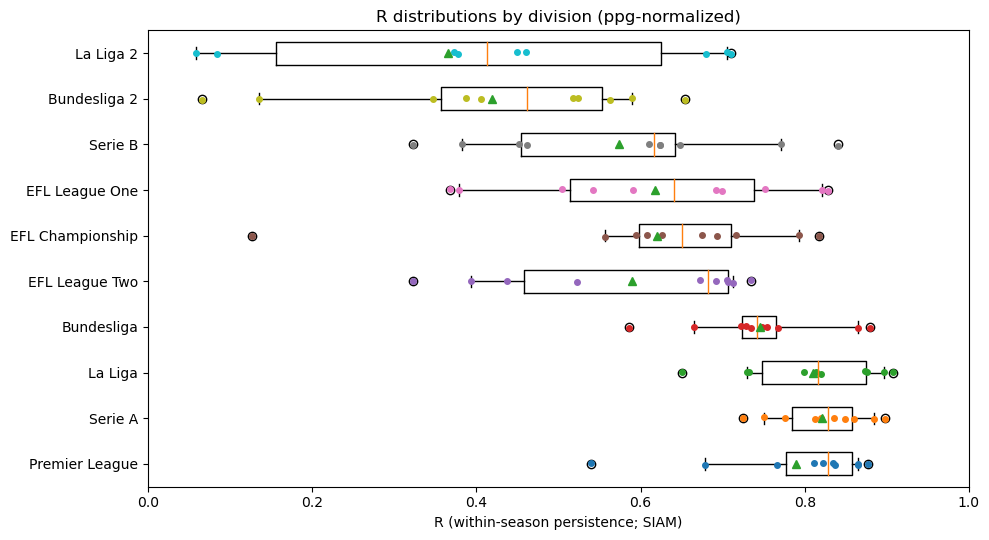

In [8]:
def plot_siam_R_boxplot(df: pd.DataFrame, metric_mode: str = "ppg"):
    # df = res_ppg.copy()
    if "metric_mode" in df.columns:
        df = df[df["metric_mode"].astype(str).str.lower()=="ppg"]

    # Sort divisions by median R, highest first
    order = (df.groupby("division")["R"]
            .median()
            .sort_values(ascending=False)
            .index
            .tolist())

    # Prepare boxplot data and scatter points
    data = [df[df["division"]==div]["R"].dropna().values for div in order]
    print(x.shape[0] for x in data)
    plt.figure(figsize=(10, 5.5))
    # Horizontal boxplot (single chart, no color specification)
    bp = plt.boxplot(data, vert=False, labels=order, manage_ticks=True, whis=[5,95], showmeans=True)

    # Overlay points for each season
    for yi, div in enumerate(order, start=1):
        vals = df[df["division"]==div]["R"].dropna().values
        if len(vals)==0: 
            continue
        y = np.full_like(vals, yi, dtype=float) + (np.random.rand(len(vals))-0.5)*0.06  # slight jitter
        plt.plot(vals, y, "o", markersize=4)

    plt.xlabel("R (within-season persistence; SIAM)")
    plt.title(f"R distributions by division ({metric_mode}-normalized)")
    plt.xlim(0, 1)
    plt.tight_layout()

    # out_path = Path("/mnt/data/siam_R_boxplot.png")
    # plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    # print("Saved to:", out_path)

plot_siam_R_boxplot(res_ppg, metric_mode="ppg")

# 2. Ver2. Variance Decomposition Style (Don't need)


In [ ]:
# Re-defining the R-value computation utilities (execution retry)
def _season_key(s):
    try:
        return int(str(s)[:4])
    except Exception:
        return s

def build_team_season_table(
    data_dict: Dict[str, Dict[str, pd.DataFrame]],
    points_win: int = 3, points_draw: int = 1, points_loss: int = 0
) -> pd.DataFrame:
    rows = []
    for season, div_map in data_dict.items():
        for division, df in div_map.items():
            needed = {"HomeTeam","AwayTeam","FTHG","FTAG"}
            if not needed.issubset(set(df.columns)):
                raise ValueError(f"{division} {season}: missing required columns {needed - set(df.columns)}")
            h = df.copy()
            h["team"] = h["HomeTeam"]
            h["gf"] = h["FTHG"]
            h["ga"] = h["FTAG"]
            a = df.copy()
            a["team"] = a["AwayTeam"]
            a["gf"] = a["FTAG"]
            a["ga"] = a["FTHG"]
            t = pd.concat([h[["team","gf","ga"]], a[["team","gf","ga"]]], ignore_index=True)
            outcome = np.sign(t["gf"] - t["ga"])
            pts = np.where(outcome>0, points_win, np.where(outcome==0, points_draw, points_loss))
            t["pts"] = pts
            t["gd"]  = t["gf"] - t["ga"]
            g = t.groupby("team", as_index=False).agg(pts=("pts","sum"),
                                                     gd=("gd","sum"),
                                                     mp=("pts","count"))
            g["division"] = division
            g["season"] = season
            rows.append(g[["division","season","team","pts","gd","mp"]])
    panel = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["division","season","team","pts","gd","mp"])
    return panel

def _adjacent_pairs(seasons: List[str]) -> List[Tuple[str,str]]:
    ss = sorted(seasons, key=_season_key)
    return list(zip(ss[:-1], ss[1:]))

def r_values_by_division(panel: pd.DataFrame, metric: str = "pts") -> Tuple[pd.DataFrame, pd.DataFrame]:
    if metric not in {"pts","gd"}:
        raise ValueError("metric must be 'pts' or 'gd'")
    details = []
    for division, df in panel.groupby("division"):
        seasons = df["season"].unique().tolist()
        for s0, s1 in _adjacent_pairs(seasons):
            a = df[df.season==s0][["team", metric]].rename(columns={metric: f"{metric}_t"})
            b = df[df.season==s1][["team", metric]].rename(columns={metric: f"{metric}_t1"})
            m = a.merge(b, on="team", how="inner")
            if len(m)>=3 and m[f"{metric}_t"].std(ddof=0)>0 and m[f"{metric}_t1"].std(ddof=0)>0:
                r = np.corrcoef(m[f"{metric}_t"], m[f"{metric}_t1"])[0,1]
                details.append({
                    "division": division,
                    "season_pair": f"{s0}→{s1}",
                    "metric": metric,
                    "teams_overlap": len(m),
                    "r": r
                })
    details_df = pd.DataFrame(details)
    if details_df.empty:
        return pd.DataFrame(columns=["division","metric","mean_r","pairs"]), details_df
    summary = details_df.groupby(["division","metric"], as_index=False).agg(mean_r=("r","mean"),
                                                                            pairs=("r","count"))
    return summary, details_df

def bootstrap_ci(x: np.ndarray, iters: int = 2000, alpha: float = 0.05, seed: int = 123) -> Tuple[float,float,float]:
    rng = np.random.default_rng(seed)
    x = np.array(x, dtype=float)
    if len(x)==0:
        return np.nan, np.nan, np.nan
    boots = [rng.choice(x, size=len(x), replace=True).mean() for _ in range(iters)]
    mu = float(x.mean())
    lo = float(np.quantile(boots, alpha/2))
    hi = float(np.quantile(boots, 1-alpha/2))
    return mu, lo, hi

def r_values_with_ci(panel: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    out_rows = []
    all_details = []
    for metric in ["pts","gd"]:
        summary, details = r_values_by_division(panel, metric=metric)
        all_details.append(details)
        for _, row in summary.iterrows():
            div = row["division"]
            subset = details[(details["division"]==div) & (details["metric"]==metric)]["r"].values
            mu, lo, hi = bootstrap_ci(subset, iters=2000, alpha=0.05, seed=123)
            out_rows.append({"division": div, "metric": metric, "mean_r": mu, "ci_lo": lo, "ci_hi": hi, "pairs": len(subset)})
    return pd.DataFrame(out_rows), pd.concat(all_details, ignore_index=True) if len(all_details) else pd.DataFrame()

In [ ]:
panel = build_team_season_table(data_dict, points_win=3, points_draw=1, points_loss=0)
summary_ci, details = r_values_with_ci(panel)

In [ ]:
panel.head()

In [ ]:
summary_ci.head()

In [ ]:
details.head()

In [ ]:
panel['devision'] = panel['division'].map(divcode2divname)
summary_ci['division'] = summary_ci['division'].map(divcode2divname)
details['division'] = details['division'].map(divcode2divname)

In [ ]:
def plot_siam_style_from_summary(summary_ci, details, metric="pts", outfile="/mnt/data/siam_style_R_{metric}.png"):
    
    s = summary_ci[summary_ci["metric"]==metric].copy()
    d = details[details["metric"]==metric].copy()
    if s.empty or d.empty:
        raise ValueError(f"No data for metric='{metric}'.")

    s = s.sort_values("mean_r", ascending=False).reset_index(drop=True)
    divisions = s["division"].tolist()
    y = np.arange(1, len(divisions)+1)

    means = s["mean_r"].values
    xerr = np.vstack([means - s["ci_lo"].values, s["ci_hi"].values - means])

    plt.figure(figsize=(10, 5.5))
    plt.errorbar(means, y, xerr=xerr, fmt='o', capsize=4)     # mean + 95% CI

    # Overlay season-pair r points (with light jitter)
    for yi, div in zip(y, divisions):
        vals = d[d["division"]==div]["r"].dropna().values
        if len(vals)==0: 
            continue
        xx = vals
        yy = np.full_like(vals, yi, dtype=float) + (np.random.rand(len(vals))-0.5)*0.06
        plt.plot(xx, yy, "o", markersize=3)

    plt.yticks(y, divisions)
    plt.xlim(0, 1)
    plt.xlabel("R (season-to-season persistence)")
    plt.title(f"League average R with 95% CI — {metric}")
    plt.annotate("Luck",  xy=(0.01, 0.02), xycoords=("axes fraction","axes fraction"))
    plt.annotate("Skill", xy=(0.99, 0.02), xycoords=("axes fraction","axes fraction"), ha="right")
    plt.tight_layout()
    # out = Path(outfile.format(metric=metric))
    # plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    # print("Saved to:", out)

# Run (save both charts: points/goal difference)
plot_siam_style_from_summary(summary_ci, details, metric="pts", outfile="/mnt/data/siam_style_R_{metric}.png")
plot_siam_style_from_summary(summary_ci, details, metric="gd",  outfile="/mnt/data/siam_style_R_{metric}.png")


# 3. Our Method (Generalized-R)

In [9]:
def update_elo(R_i, R_j, outcome_i, K=20, H=0):
    """Elo update after a single match."""
    E_i = 1.0 / (1 + 10 ** ((R_j - R_i + H) / 400))
    E_j = 1.0 - E_i
    R_i_new = R_i + K * (outcome_i - E_i)
    R_j_new = R_j + K * ((1 - outcome_i) - E_j)
    return R_i_new, R_j_new

def compute_elo_ratings(df, base_rating=1500, K=20):
    """Track Elo for all teams within a season and record pre-match Elos for each match."""
    teams = sorted(set(df["HomeTeam"]).union(set(df["AwayTeam"])))
    ratings = {t: base_rating for t in teams}
    pre_elos = []

    for _, row in df.sort_values("Date").iterrows():
        ht, at = row["HomeTeam"], row["AwayTeam"]
        hg, ag = row["FTHG"], row["FTAG"]

        if hg > ag: outcome_h = 1.0
        elif hg == ag: outcome_h = 0.5
        else: outcome_h = 0.0

        R_h, R_a = ratings[ht], ratings[at]
        pre_elos.append({"Date": row["Date"], "HomeTeam": ht, "AwayTeam": at,
                         "HomeElo": R_h, "AwayElo": R_a})

        new_R_h, new_R_a = update_elo(R_h, R_a, outcome_h, K=K)
        ratings[ht], ratings[at] = new_R_h, new_R_a

    pre_df = pd.DataFrame(pre_elos)
    df = df.merge(pre_df, on=["Date","HomeTeam","AwayTeam"], how="left")
    return df


def stratified_split(team_df, rng, eps=0.05, metric_mode="ppg"):
    """
    Split a team's matches into two folds (A, B).
    - Stratify to balance opponent Elo distribution
    - Include random tie-breaking
    """
    matches = team_df.copy()
    matches = matches.sort_values("Date")

    # Gather opponent Elo
    opp_elos = []
    for _, row in matches.iterrows():
        if row["venue"] == "H":
            opp_elos.append(row["AwayElo"])
        else:
            opp_elos.append(row["HomeElo"])
    matches["opp_elo"] = opp_elos

    # Bin by Elo quantiles
    bins = pd.qcut(matches["opp_elo"], q=min(5, len(matches)), duplicates="drop")
    matches["elo_bin"] = bins

    A_idx, B_idx = [], []
    for _, g in matches.groupby("elo_bin"):
        idxs = g.index.tolist()
        rng.shuffle(idxs)
        half = len(idxs) // 2
        A_idx.extend(idxs[:half])
        B_idx.extend(idxs[half:])

    A = matches.loc[A_idx]
    B = matches.loc[B_idx]

    return A, B

def performance_metric(fold_df, metric_mode="ppg"):
    if len(fold_df) == 0:
        return np.nan
    if metric_mode == "ppg":
        pts = fold_df["pts"].sum()
        return (pts / len(fold_df)) / 3.0
    elif metric_mode == "winfrac":
        wins = fold_df["win"].sum()
        return wins / len(fold_df)
    else:
        raise ValueError("metric_mode must be 'ppg' or 'winfrac'")


def compute_generalized_R(data_dict, metric_mode="ppg", K=200, seed=123):
    rng = np.random.default_rng(seed)
    rows = []
    for season, divmap in data_dict.items():
        for division, df in divmap.items():
            # Precompute Elo ratings
            df = df[(df['HomeTeam'].notna()) & (df['AwayTeam'].notna())]
            df = compute_elo_ratings(df)

            teams = sorted(set(df["HomeTeam"]).union(set(df["AwayTeam"])))
            XY_all = []
            for team in teams:
                trows = _team_rows(df, team, method="ours")  # Reuse function defined earlier
                if len(trows) < 4:
                    continue
                # Repeat K splits per team
                for k in range(K):
                    A, B = stratified_split(trows, rng, metric_mode=metric_mode)
                    x = performance_metric(A, metric_mode)
                    y = performance_metric(B, metric_mode)
                    if np.isfinite(x) and np.isfinite(y):
                        XY_all.append((x,y))
            if len(XY_all) >= 3:
                X = np.array([u for u,v in XY_all])
                Y = np.array([v for u,v in XY_all])
                S = (X + Y)/np.sqrt(2)
                T = (Y - X)/np.sqrt(2)
                A_var = np.var(S, ddof=0)
                B_var = np.var(T, ddof=0)
                R = 1 - B_var/A_var if A_var > 1e-12 else np.nan
                rows.append({"division": division, "season": season, 
                             "metric_mode": metric_mode, "teams": len(teams), "R_g": R})
    return pd.DataFrame(rows)


In [10]:
import warnings
warnings.filterwarnings("ignore")  # Hide all warnings

gen_df = compute_generalized_R(data_dict, metric_mode='ppg', K=3)
gen_df.head()

,division,season,metric_mode,teams,R_g
0,E0,1516,ppg,20,0.799516
1,E1,1516,ppg,24,0.732473
2,E2,1516,ppg,24,0.674024
3,E3,1516,ppg,24,0.638059
4,D1,1516,ppg,18,0.749268


In [11]:
divcode2divname = {
    'E0': 'Premier League',
    'E1': 'EFL Championship',
    'E2': 'EFL League One',
    'E3': 'EFL League Two',
    "D1": "Bundesliga",
    "D2": "Bundesliga 2",
    "I1": "Serie A",
    "I2": "Serie B",
    "SP1": "La Liga",
    "SP2": "La Liga 2",
    # "wc": "World Cup"
}
gen_df["division"] = gen_df["division"].map(divcode2divname)

gen_df['R'] = gen_df['R_g']

gen_df.head()

,division,season,metric_mode,teams,R_g,R
0,Premier League,1516,ppg,20,0.799516,0.799516
1,EFL Championship,1516,ppg,24,0.732473,0.732473
2,EFL League One,1516,ppg,24,0.674024,0.674024
3,EFL League Two,1516,ppg,24,0.638059,0.638059
4,Bundesliga,1516,ppg,18,0.749268,0.749268


In [12]:
gen_df.head()

,division,season,metric_mode,teams,R_g,R
0,Premier League,1516,ppg,20,0.799516,0.799516
1,EFL Championship,1516,ppg,24,0.732473,0.732473
2,EFL League One,1516,ppg,24,0.674024,0.674024
3,EFL League Two,1516,ppg,24,0.638059,0.638059
4,Bundesliga,1516,ppg,18,0.749268,0.749268


In [13]:
df = gen_df.copy()

# Sort divisions by median R, highest first
order = (df.groupby("division")["R"]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist())
# Prepare boxplot data and scatter points
data = [df[df["division"]==div]["R"].dropna().values for div in order]
# order = [divcode2divname[x] for x in order]

plt.figure(figsize=(10, 5.5))
# Horizontal boxplot (single chart, no color specification)
bp = plt.boxplot(data, vert=False, labels=order, manage_ticks=True, whis=[5,95], showmeans=True)
# Overlay points for each season
for yi, div in enumerate(order, start=1):
    vals = df[df["division"]==div]["R"].dropna().values
    if len(vals)==0: 
        continue
    y = np.full_like(vals, yi, dtype=float) + (np.random.rand(len(vals))-0.5)*0.06  # slight jitter
    plt.plot(vals, y, "o", markersize=4)

plt.xlabel("Generalized R")
plt.title(f"R distributions by division (winfrac-normalized)")
plt.xlim(0, 1)
plt.tight_layout()


In [14]:
siam_df = res_ppg.copy()

# Keep only required columns and normalize schema
siam_plot = siam_df[["division", "season", "R"]].copy()
siam_plot["method"] = "Getty R (Traditional)"   # SIAM-style baseline in your notebook
print (siam_plot.head())

# Prepare Generalized R data for plotting
gen_plot = gen_df[["division", "season", "R"]].copy()
gen_plot["method"] = "Generalized R"

print (siam_plot.head())

plot_df = pd.concat([gen_plot, siam_plot], ignore_index=True)
print (plot_df.head())
plot_df["R"] = pd.to_numeric(plot_df["R"], errors="coerce")
plot_df = plot_df.dropna(subset=["R"])


      division season         R                 method
4   Bundesliga   1516  0.865222  Getty R (Traditional)
14  Bundesliga   1617  0.665406  Getty R (Traditional)
24  Bundesliga   1718  0.728517  Getty R (Traditional)
34  Bundesliga   1819  0.879282  Getty R (Traditional)
44  Bundesliga   1920  0.721963  Getty R (Traditional)
      division season         R                 method
4   Bundesliga   1516  0.865222  Getty R (Traditional)
14  Bundesliga   1617  0.665406  Getty R (Traditional)
24  Bundesliga   1718  0.728517  Getty R (Traditional)
34  Bundesliga   1819  0.879282  Getty R (Traditional)
44  Bundesliga   1920  0.721963  Getty R (Traditional)
           division season         R         method
0    Premier League   1516  0.799516  Generalized R
1  EFL Championship   1516  0.732473  Generalized R
2    EFL League One   1516  0.674024  Generalized R
3    EFL League Two   1516  0.638059  Generalized R
4        Bundesliga   1516  0.749268  Generalized R


In [15]:
## read mls and ucl data
mls_r = pd.read_csv("/Users/abcd/Documents/skill-vs-luck/data/processed_10Feb/mls_r_values_for_combined_analysis.csv")
ucl_r = pd.read_csv("/Users/abcd/Documents/skill-vs-luck/data/processed_10Feb/ucl_processed_R.csv")
print (mls_r.head())
print (ucl_r.head())

## keep only relevant columns and add method labels
mls_plot = mls_r[["division", "season", "R", "method"]].copy()
ucl_plot = ucl_r[["division", "season", "R", "method"]].copy()
print (mls_plot.head())
print (ucl_plot.head())

  division  season metric_mode  teams         R         method
0      MLS    2013         ppg     19  0.544991  Generalized R
1      MLS    2014         ppg     19  0.505964  Generalized R
2      MLS    2015         ppg     20 -0.037566  Generalized R
3      MLS    2016         ppg     20  0.118117  Generalized R
4      MLS    2017         ppg     22  0.292662  Generalized R
  division   season  teams metric_mode         R                 method
0      UCL  2016-17     32         ppg  0.624856  Getty R (Traditional)
1      UCL  2016-17     32         ppg  0.414791          Generalized R
2      UCL  2017-18     32         ppg  0.588325  Getty R (Traditional)
3      UCL  2017-18     32         ppg  0.542287          Generalized R
4      UCL  2018-19     32         ppg  0.353268  Getty R (Traditional)
  division  season         R         method
0      MLS    2013  0.544991  Generalized R
1      MLS    2014  0.505964  Generalized R
2      MLS    2015 -0.037566  Generalized R
3      MLS    

In [16]:
## concentrate all data for plotting
combined_plot = pd.concat([plot_df, mls_plot, ucl_plot], ignore_index=True)
print (combined_plot.head())

           division season         R         method
0    Premier League   1516  0.799516  Generalized R
1  EFL Championship   1516  0.732473  Generalized R
2    EFL League One   1516  0.674024  Generalized R
3    EFL League Two   1516  0.638059  Generalized R
4        Bundesliga   1516  0.749268  Generalized R


In [17]:
print ("BL2")
print (combined_plot[combined_plot['division']=='Bundesliga 2'])

BL2
         division season         R                 method
5    Bundesliga 2   1516  0.511337          Generalized R
15   Bundesliga 2   1617  0.752642          Generalized R
25   Bundesliga 2   1718  0.247674          Generalized R
35   Bundesliga 2   1819  0.380410          Generalized R
45   Bundesliga 2   1920  0.245462          Generalized R
55   Bundesliga 2   2021  0.642343          Generalized R
65   Bundesliga 2   2122  0.679779          Generalized R
75   Bundesliga 2   2223  0.618199          Generalized R
85   Bundesliga 2   2324  0.201687          Generalized R
95   Bundesliga 2   2425  0.046870          Generalized R
110  Bundesliga 2   1516  0.653851  Getty R (Traditional)
111  Bundesliga 2   1617  0.405521  Getty R (Traditional)
112  Bundesliga 2   1718  0.386909  Getty R (Traditional)
113  Bundesliga 2   1819  0.066076  Getty R (Traditional)
114  Bundesliga 2   1920  0.589556  Getty R (Traditional)
115  Bundesliga 2   2021  0.562918  Getty R (Traditional)
116  Bunde

In [18]:
print ("La2")
print (combined_plot[combined_plot['division']=='La Liga 2'])

La2
      division season         R                 method
9    La Liga 2   1516  0.434598          Generalized R
19   La Liga 2   1617  0.420422          Generalized R
29   La Liga 2   1718  0.498237          Generalized R
39   La Liga 2   1819  0.729295          Generalized R
49   La Liga 2   1920  0.223172          Generalized R
59   La Liga 2   2021  0.594027          Generalized R
69   La Liga 2   2122  0.748905          Generalized R
79   La Liga 2   2223  0.292386          Generalized R
89   La Liga 2   2324  0.151355          Generalized R
99   La Liga 2   2425  0.258223          Generalized R
190  La Liga 2   1516  0.461034  Getty R (Traditional)
191  La Liga 2   1617  0.679594  Getty R (Traditional)
192  La Liga 2   1718  0.449067  Getty R (Traditional)
193  La Liga 2   1819  0.705769  Getty R (Traditional)
194  La Liga 2   1920  0.083902  Getty R (Traditional)
195  La Liga 2   2021  0.377408  Getty R (Traditional)
196  La Liga 2   2122  0.710773  Getty R (Traditional)
197  L

In [ ]:

# ------------------------------------------------------------
# 2) Order divisions by Generalized R median (descending)
# ------------------------------------------------------------
combined_plot = combined_plot[combined_plot['division'].isin(['Premier League', 'EFL Championship', 'Bundesliga', 'Bundesliga 2', 'Serie A',
       'Serie B', 'La Liga', 'La Liga 2', 'MLS', 'UCL'])]

combined_median_order = (
    combined_plot.loc[combined_plot["method"] == "Generalized R"]
    .groupby("division")["R"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

combined_plot["x_label"] = combined_plot["division"]
final_x_order = [x for x in combined_median_order if x not in ['UCL', 'MLS']] + ['UCL', 'MLS']

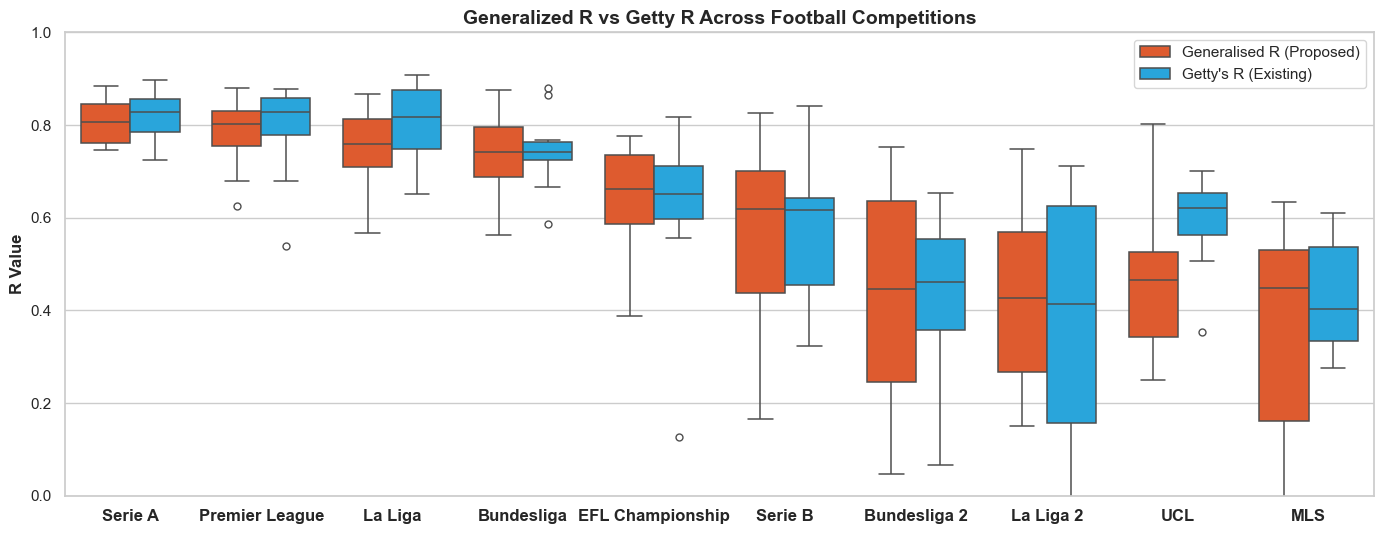

In [50]:
# ------------------------------------------------------------
# 3) Draw paired boxplots
# ------------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 5.5))

palette = {
    "Generalized R": "#FB4C1299",
    "Getty R (Traditional)": "#0CB1F8AF",
}

sns.boxplot(
    data=combined_plot,
    x="x_label",
    y="R",
    hue="method",
    order=final_x_order,
    hue_order=["Generalized R", "Getty R (Traditional)"],
    palette=palette,
    width=0.75,
    linewidth=1.1,
    fliersize=5,
    ax=ax,
)

handles, labels = ax.get_legend_handles_labels()
new_labels = ["Generalised R (Proposed)", "Getty's R (Existing)"]

ax.set_title("Generalized R vs Getty R Across Football Competitions", fontsize=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("R Value", fontsize=12, weight="bold")
ax.set_ylim(0, 1.0)
ax.tick_params(axis="x")
for label in ax.get_xticklabels():
    label.set_fontweight('bold')  # Set each x-label to bold
    label.set_fontsize(12)
ax.legend(handles=handles, labels=new_labels, title=None, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()